In [1]:
import sys
import os

sys.path.append(os.path.abspath(os.path.join('..', '..')))

import argparse
from pprint import pp
import torch
from torch import nn
from tqdm import tqdm
import numpy as np
import json
import os
from omegaconf import OmegaConf
from torch.utils.tensorboard import SummaryWriter

from lpn.utils import load_dataset, load_config
from lpn.utils import get_model
from lpn.utils import get_loss_hparams_and_lr, get_loss
from lpn.utils import trainer
from lpn.utils import utils
import matplotlib.pyplot as plt

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [3]:
lpn_model_config_path = os.path.join('..','models','lpn','s=0.1','model_config.json')
lpn_model_weight_path = os.path.join('..','models','lpn','s=0.1','model.pt')

lpn_model_config = load_config(lpn_model_config_path)
lpn_model = get_model(lpn_model_config)
lpn_model.load_state_dict(torch.load(lpn_model_weight_path)['model_state_dict'])
lpn_model.to(device)

init weights


LPN(
  (lin): ModuleList(
    (0): Conv2d(3, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): Conv2d(256, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (3): Conv2d(256, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (4): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (5): Conv2d(256, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (6): Conv2d(256, 64, kernel_size=(16, 16), stride=(1, 1), bias=False)
    (7): Linear(in_features=64, out_features=1, bias=True)
  )
  (res): ModuleList(
    (0): Conv2d(3, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): Conv2d(3, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (2): Conv2d(3, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (3): Conv2d(3, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 

In [4]:
ne_lpn_model_config_path = os.path.join('..','models','ne_lpn','s=0.1','model_config.json')
ne_lpn_model_weight_path = os.path.join('..','models','ne_lpn','s=0.1','model.pt')
ne_lpn_model_config = load_config(ne_lpn_model_config_path)
ne_lpn_model = get_model(ne_lpn_model_config)
ne_lpn_model.load_state_dict(torch.load(ne_lpn_model_weight_path)['model_state_dict'])
ne_lpn_model.to(device)

init weights


LPN(
  (lin): ModuleList(
    (0): Conv2d(3, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (1): Conv2d(256, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (3): Conv2d(256, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (4): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (5): Conv2d(256, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (6): Conv2d(256, 64, kernel_size=(16, 16), stride=(1, 1), bias=False)
    (7): Linear(in_features=64, out_features=1, bias=False)
  )
  (res): ModuleList(
    (0): Conv2d(3, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (1): Conv2d(3, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (2): Conv2d(3, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (3): Conv2d(3, 256

In [5]:
ne_lpn_by_forward_model_config_path = '../models/ne_by_forward_lpn/s=0.1/model_config.json'
ne_lpn_by_forward_model_weight_path = '../models/ne_by_forward_lpn/s=0.1/model.pt'
ne_lpn_by_forward_model_config = load_config(ne_lpn_by_forward_model_config_path)
ne_lpn_by_forward_model = get_model(ne_lpn_by_forward_model_config)
ne_lpn_by_forward_model.load_state_dict(torch.load(ne_lpn_by_forward_model_weight_path)['model_state_dict'])
ne_lpn_by_forward_model.to(device)

init weights


LPN(
  (lin): ModuleList(
    (0): Conv2d(3, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): Conv2d(256, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (3): Conv2d(256, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (4): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (5): Conv2d(256, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (6): Conv2d(256, 64, kernel_size=(16, 16), stride=(1, 1), bias=False)
    (7): Linear(in_features=64, out_features=1, bias=True)
  )
  (res): ModuleList(
    (0): Conv2d(3, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): Conv2d(3, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (2): Conv2d(3, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (3): Conv2d(3, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 

In [6]:
ne_lpn_normalized_and_scaled_model_config_path = '../models/ne_norm_and_scaled_lpn/s=0.1/model_config.json'
ne_lpn_normalized_and_scaled_model_weight_path = '../models/ne_norm_and_scaled_lpn/s=0.1/model.pt'
ne_lpn_normalized_and_scaled_model_config = load_config(ne_lpn_normalized_and_scaled_model_config_path)
ne_lpn_normalized_and_scaled_model = get_model(ne_lpn_normalized_and_scaled_model_config)
ne_lpn_normalized_and_scaled_model.load_state_dict(torch.load(ne_lpn_normalized_and_scaled_model_weight_path)['model_state_dict'])
ne_lpn_normalized_and_scaled_model.to(device)

init weights


LPN(
  (lin): ModuleList(
    (0): Conv2d(3, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (1): Conv2d(256, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (3): Conv2d(256, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (4): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (5): Conv2d(256, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (6): Conv2d(256, 64, kernel_size=(16, 16), stride=(1, 1), bias=False)
    (7): Linear(in_features=64, out_features=1, bias=False)
  )
  (res): ModuleList(
    (0): Conv2d(3, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (1): Conv2d(3, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (2): Conv2d(3, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (3): Conv2d(3, 256

In [7]:
drunet_model_config_path = '../models/drunet/s=0.1/model_config.json'
drunet_model_weight_path = '../models/drunet/s=0.1/model.pt'
drunet_model_config = load_config(drunet_model_config_path)
drunet_model = get_model(drunet_model_config)
drunet_model.load_state_dict(torch.load(drunet_model_weight_path)['model_state_dict'])
drunet_model.to(device)

DRUNet(
  (m_head): AffineConv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False, padding_mode=reflect)
  (m_down): ModuleList(
    (0): Sequential(
      (0): ResBlock(
        (m_res): Sequential(
          (0): AffineConv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False, padding_mode=reflect)
          (1): SortPool()
          (2): AffineConv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False, padding_mode=reflect)
        )
        (sum): ResidualConnection()
      )
      (1): ResBlock(
        (m_res): Sequential(
          (0): AffineConv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False, padding_mode=reflect)
          (1): SortPool()
          (2): AffineConv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False, padding_mode=reflect)
        )
        (sum): ResidualConnection()
      )
      (2): ResBlock(
        (m_res): Sequential(
          (0): AffineConv2d(64, 64, 

In [8]:
ne_lpn_64ch_model_config_path = '../models/backup_temp/ne_lpn_64ch_s=0.1/model_config.json'
ne_lpn_64ch_model_weight_path = '../models/backup_temp/ne_lpn_64ch_s=0.1/model.pt'
ne_lpn_64ch_model_config = load_config(ne_lpn_64ch_model_config_path)
ne_lpn_64ch_model = get_model(ne_lpn_64ch_model_config)
ne_lpn_64ch_model.load_state_dict(torch.load(ne_lpn_64ch_model_weight_path)['model_state_dict'])
ne_lpn_64ch_model.to(device)

init weights


LPN(
  (lin): ModuleList(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (1): Conv2d(64, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (4): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (5): Conv2d(64, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (6): Conv2d(64, 64, kernel_size=(16, 16), stride=(1, 1), bias=False)
    (7): Linear(in_features=64, out_features=1, bias=False)
  )
  (res): ModuleList(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (1): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (2): Conv2d(3, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (3): Conv2d(3, 64, kernel_size=(3

In [9]:
ne_lpn_norm_and_scaled_wbias = '../models/ne_norm_and_scaled_wbias_lpn/s=0.1/model.pt'
ne_lpn_norm_and_scaled_wbias_config_path = '../models/ne_norm_and_scaled_wbias_lpn/s=0.1/model_config.json'
ne_lpn_norm_and_scaled_wbias_config = load_config(ne_lpn_norm_and_scaled_wbias_config_path)
ne_lpn_norm_and_scaled_wbias_model = get_model(ne_lpn_norm_and_scaled_wbias_config)
ne_lpn_norm_and_scaled_wbias_model.load_state_dict(torch.load(ne_lpn_norm_and_scaled_wbias)['model_state_dict'])
ne_lpn_norm_and_scaled_wbias_model.to(device)

init weights


LPN(
  (lin): ModuleList(
    (0): Conv2d(3, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): Conv2d(256, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (3): Conv2d(256, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (4): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (5): Conv2d(256, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (6): Conv2d(256, 64, kernel_size=(16, 16), stride=(1, 1), bias=False)
    (7): Linear(in_features=64, out_features=1, bias=True)
  )
  (res): ModuleList(
    (0): Conv2d(3, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): Conv2d(3, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (2): Conv2d(3, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (3): Conv2d(3, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 

In [10]:
dataset_config_path = os.path.join('..','configs','dataset.json')
dataset_config = load_config(dataset_config_path)
dataset_config['params']['root'] = '../../../data/bsds500'
test_dataset = load_dataset(dataset_config, 'test')
test_dataloader = torch.utils.data.DataLoader(test_dataset, batch_size=1, shuffle=False, num_workers=4)

dataset:  bsds500


In [11]:
def visualize_dataloader(dataloader):
    for i, data in enumerate(dataloader):
        image = data['image'].squeeze(0).permute(1, 2, 0).cpu().numpy()
        plt.imshow(image)
        plt.show()
        if i == 5:
            break
#visualize_dataloader(test_dataloader)  #uncomment to visualize

In [12]:
noise_levels = [0.05,0.1,0.2,0.3,0.4,0.5,0.6,0.7]

In [13]:
from skimage.metrics import peak_signal_noise_ratio as skimage_psnr
from skimage.metrics import structural_similarity as skimage_ssim

def evaluate_model(model, dataloader, noise_levels):
    model.eval()
    avg_psnr_list = []
    avg_ssim_list = []

    for noise in tqdm(noise_levels, total=len(noise_levels)):
        psnr_list = []
        ssim_list = []
        for i, data in tqdm(enumerate(dataloader), total=len(dataloader)):
            img = data['image'].to(device)
            noise_tensor = torch.randn_like(img) * noise
            noisy_img = img + noise_tensor

            with torch.no_grad():
                denoised_img = model(noisy_img)

            img_np = img.squeeze(0).permute(1, 2, 0).cpu().detach().numpy() 
            denoised_np = denoised_img.squeeze(0).permute(1, 2, 0).cpu().detach().numpy()

            psnr = skimage_psnr(img_np, denoised_np, data_range=1.0)
            ssim = skimage_ssim(img_np, denoised_np, data_range=1.0, channel_axis=-1)

            psnr_list.append(psnr)
            ssim_list.append(ssim)
        avg_psnr = np.mean(psnr_list)
        avg_ssim = np.mean(ssim_list)
        avg_psnr_list.append(avg_psnr)
        avg_ssim_list.append(avg_ssim)
        print(f"Average PSNR for noise level {noise}: {avg_psnr:.2f}")
        print(f"Average SSIM for noise level {noise}: {avg_ssim:.4f}")
    return avg_psnr_list, avg_ssim_list


In [14]:
lpn_psnr, lpn_ssim = evaluate_model(lpn_model, test_dataloader, noise_levels)

  0%|          | 0/8 [00:00<?, ?it/s]

 12%|█▎        | 1/8 [00:05<00:39,  5.69s/it]

Average PSNR for noise level 0.05: 31.20
Average SSIM for noise level 0.05: 0.8822


 25%|██▌       | 2/8 [00:08<00:23,  3.86s/it]

Average PSNR for noise level 0.1: 29.56
Average SSIM for noise level 0.1: 0.8602


...

Average PSNR for noise level 0.5: 5.28
Average SSIM for noise level 0.5: 0.0828


 88%|████████▊ | 7/8 [00:21<00:02,  2.78s/it]

Average PSNR for noise level 0.6: 1.55
Average SSIM for noise level 0.6: 0.0411


100%|██████████| 8/8 [00:24<00:00,  3.04s/it]

Average PSNR for noise level 0.7: -1.38
Average SSIM for noise level 0.7: 0.0187


In [15]:
ne_lpn_psnr, ne_lpn_ssim = evaluate_model(ne_lpn_model, test_dataloader, noise_levels)

 12%|█▎        | 1/8 [00:03<00:21,  3.11s/it]

Average PSNR for noise level 0.05: 23.57
Average SSIM for noise level 0.05: 0.7633


 25%|██▌       | 2/8 [00:06<00:18,  3.15s/it]

Average PSNR for noise level 0.1: 23.31
Average SSIM for noise level 0.1: 0.7130


 38%|███▊      | 3/8 [00:09<00:15,  3.13s/it]

...

Average PSNR for noise level 0.5: 16.44
Average SSIM for noise level 0.5: 0.2959


 88%|████████▊ | 7/8 [00:21<00:03,  3.14s/it]

Average PSNR for noise level 0.6: 15.04
Average SSIM for noise level 0.6: 0.2444


100%|██████████| 8/8 [00:25<00:00,  3.14s/it]

Average PSNR for noise level 0.7: 13.81
Average SSIM for noise level 0.7: 0.2050


In [16]:
ne_lpn_64ch_psnr, ne_lpn_64ch_ssim = evaluate_model(ne_lpn_64ch_model, test_dataloader, noise_levels)

 12%|█▎        | 1/8 [00:02<00:18,  2.71s/it]

Average PSNR for noise level 0.05: 23.12
Average SSIM for noise level 0.05: 0.7629


 25%|██▌       | 2/8 [00:05<00:16,  2.70s/it]

Average PSNR for noise level 0.1: 22.82
Average SSIM for noise level 0.1: 0.7251


 38%|███▊      | 3/8 [00:08<00:13,  2.69s/it]

...

Average PSNR for noise level 0.5: 16.39
Average SSIM for noise level 0.5: 0.3029


 88%|████████▊ | 7/8 [00:19<00:02,  2.73s/it]

Average PSNR for noise level 0.6: 15.05
Average SSIM for noise level 0.6: 0.2497


100%|██████████| 8/8 [00:21<00:00,  2.72s/it]

Average PSNR for noise level 0.7: 13.85
Average SSIM for noise level 0.7: 0.2089


In [17]:
ne_by_forward_psnr, ne_by_forward_ssim = evaluate_model(ne_lpn_by_forward_model, test_dataloader, noise_levels)

 12%|█▎        | 1/8 [00:02<00:18,  2.65s/it]

Average PSNR for noise level 0.05: 31.03
Average SSIM for noise level 0.05: 0.8858


 25%|██▌       | 2/8 [00:05<00:16,  2.72s/it]

Average PSNR for noise level 0.1: 29.09
Average SSIM for noise level 0.1: 0.8444


 38%|███▊      | 3/8 [00:08<00:13,  2.72s/it]

...

Average PSNR for noise level 0.5: 17.25
Average SSIM for noise level 0.5: 0.3354


 88%|████████▊ | 7/8 [00:18<00:02,  2.67s/it]

Average PSNR for noise level 0.6: 15.76
Average SSIM for noise level 0.6: 0.2770


100%|██████████| 8/8 [00:21<00:00,  2.69s/it]

Average PSNR for noise level 0.7: 14.53
Average SSIM for noise level 0.7: 0.2348


In [18]:
ne_norm_and_scaled_psnr, ne_norm_and_scaled_ssim = evaluate_model(ne_lpn_normalized_and_scaled_model, test_dataloader, noise_levels)

 12%|█▎        | 1/8 [00:03<00:22,  3.18s/it]

Average PSNR for noise level 0.05: 23.78
Average SSIM for noise level 0.05: 0.7725


 25%|██▌       | 2/8 [00:06<00:18,  3.11s/it]

Average PSNR for noise level 0.1: 23.49
Average SSIM for noise level 0.1: 0.7233


 38%|███▊      | 3/8 [00:09<00:15,  3.11s/it]

...

Average PSNR for noise level 0.5: 16.64
Average SSIM for noise level 0.5: 0.3004


 88%|████████▊ | 7/8 [00:21<00:03,  3.11s/it]

Average PSNR for noise level 0.6: 15.25
Average SSIM for noise level 0.6: 0.2484


100%|██████████| 8/8 [00:24<00:00,  3.11s/it]

Average PSNR for noise level 0.7: 14.04
Average SSIM for noise level 0.7: 0.2078


In [19]:
ne_norm_and_scaled_wbias_psnr, ne_norm_and_scaled_wbias_ssim = evaluate_model(ne_lpn_norm_and_scaled_wbias_model, test_dataloader, noise_levels)

 12%|█▎        | 1/8 [00:03<00:22,  3.26s/it]

Average PSNR for noise level 0.05: 28.82
Average SSIM for noise level 0.05: 0.8567


 25%|██▌       | 2/8 [00:06<00:19,  3.20s/it]

Average PSNR for noise level 0.1: 27.58
Average SSIM for noise level 0.1: 0.8086


 38%|███▊      | 3/8 [00:09<00:16,  3.24s/it]

...

Average PSNR for noise level 0.5: 16.48
Average SSIM for noise level 0.5: 0.2997


 88%|████████▊ | 7/8 [00:22<00:03,  3.17s/it]

Average PSNR for noise level 0.6: 14.86
Average SSIM for noise level 0.6: 0.2447


100%|██████████| 8/8 [00:25<00:00,  3.16s/it]

Average PSNR for noise level 0.7: 13.50
Average SSIM for noise level 0.7: 0.2027


In [20]:
drunet_psnr, drunet_ssim = evaluate_model(drunet_model, test_dataloader, noise_levels)

 12%|█▎        | 1/8 [00:04<00:31,  4.55s/it]

Average PSNR for noise level 0.05: 33.44
Average SSIM for noise level 0.05: 0.9376


 25%|██▌       | 2/8 [00:09<00:27,  4.56s/it]

Average PSNR for noise level 0.1: 30.29
Average SSIM for noise level 0.1: 0.8836


 38%|███▊      | 3/8 [00:13<00:22,  4.57s/it]

...

Average PSNR for noise level 0.5: 22.77
Average SSIM for noise level 0.5: 0.5881


 88%|████████▊ | 7/8 [00:31<00:04,  4.56s/it]

Average PSNR for noise level 0.6: 21.97
Average SSIM for noise level 0.6: 0.5408


100%|██████████| 8/8 [00:36<00:00,  4.57s/it]

Average PSNR for noise level 0.7: 21.31
Average SSIM for noise level 0.7: 0.5004


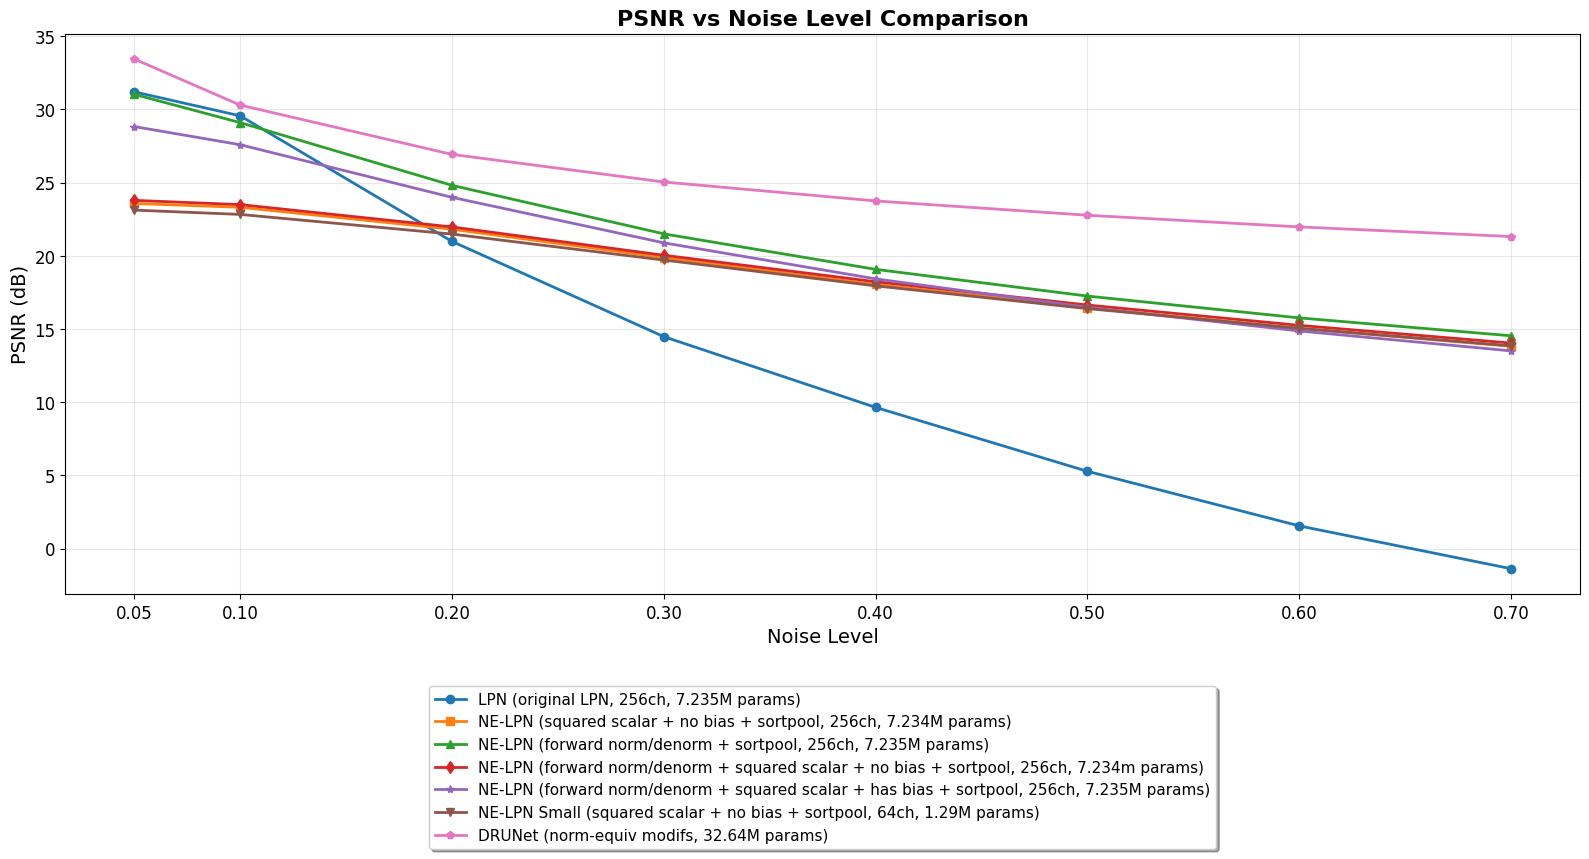

In [ ]:
plt.figure(figsize=(16, 8))  # Much wider figure

# Plotting lines with better styling
plt.plot(noise_levels, lpn_psnr, label='LPN (original LPN, 256ch, 7.235M params)', linewidth=2, marker='o')
plt.plot(noise_levels, ne_lpn_psnr, label='NE-LPN (squared scalar + no bias + sortpool, 256ch, 7.234M params)', linewidth=2, marker='s')
plt.plot(noise_levels, ne_by_forward_psnr, label='NE-LPN (forward norm/denorm + has bias + sortpool, 256ch, 7.235M params)', linewidth=2, marker='^')
plt.plot(noise_levels, ne_norm_and_scaled_psnr, label='NE-LPN (forward norm/denorm + squared scalar + no bias + sortpool, 256ch, 7.234m params)', linewidth=2, marker='d')
plt.plot(noise_levels, ne_norm_and_scaled_wbias_psnr, label='NE-LPN (forward norm/denorm + squared scalar + has bias + sortpool, 256ch, 7.235M params)', linewidth=2, marker='*')
plt.plot(noise_levels, ne_lpn_64ch_psnr, label='NE-LPN Small (squared scalar + no bias + sortpool, 64ch, 1.29M params)', linewidth=2, marker='v')
plt.plot(noise_levels, drunet_psnr, label='DRUNet (norm-equiv modifs, 32.64M params)', linewidth=2, marker='p')

plt.xlabel('Noise Level', fontsize=14)
plt.ylabel('PSNR (dB)', fontsize=14)
plt.title('PSNR vs Noise Level Comparison', fontsize=16, fontweight='bold')
plt.xticks(noise_levels, fontsize=12)
plt.yticks(fontsize=12)
plt.grid(True, alpha=0.3)

# Legend below the plot with single column for readability
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), 
          ncol=1, fontsize=11, frameon=True, fancybox=True, shadow=True)

# Adjust layout to accommodate legend below
plt.tight_layout()
plt.subplots_adjust(bottom=0.25)  # Make room for legend

plt.show()